Continuing from makemore 1

* we are updating representation
    * Removing <E> entirely (to remove one character)
    * Replacing \<S> with '.'
* create bigram model (basically probabilities learned from distribution of bigram counter)
* compare bigram model (from learned probabilities) with equally distributed probabilities --> This will tell what exactly did bigram model learn

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
import torch

#### representing above bigram dictionary in torch matrix

In [5]:
# we will need 26 * 26 for all alphabets + 1 for start char
# so 27 * 27
N = torch.zeros((27, 27), dtype = torch.int32)

# a - z
chars = sorted(list(set(''.join(words))))
stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [10]:
# N will have bigram counter

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1, index2] += 1

In [8]:
# inverting the presentation
# if stoi mapped character to index
# itos in inverted s

itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

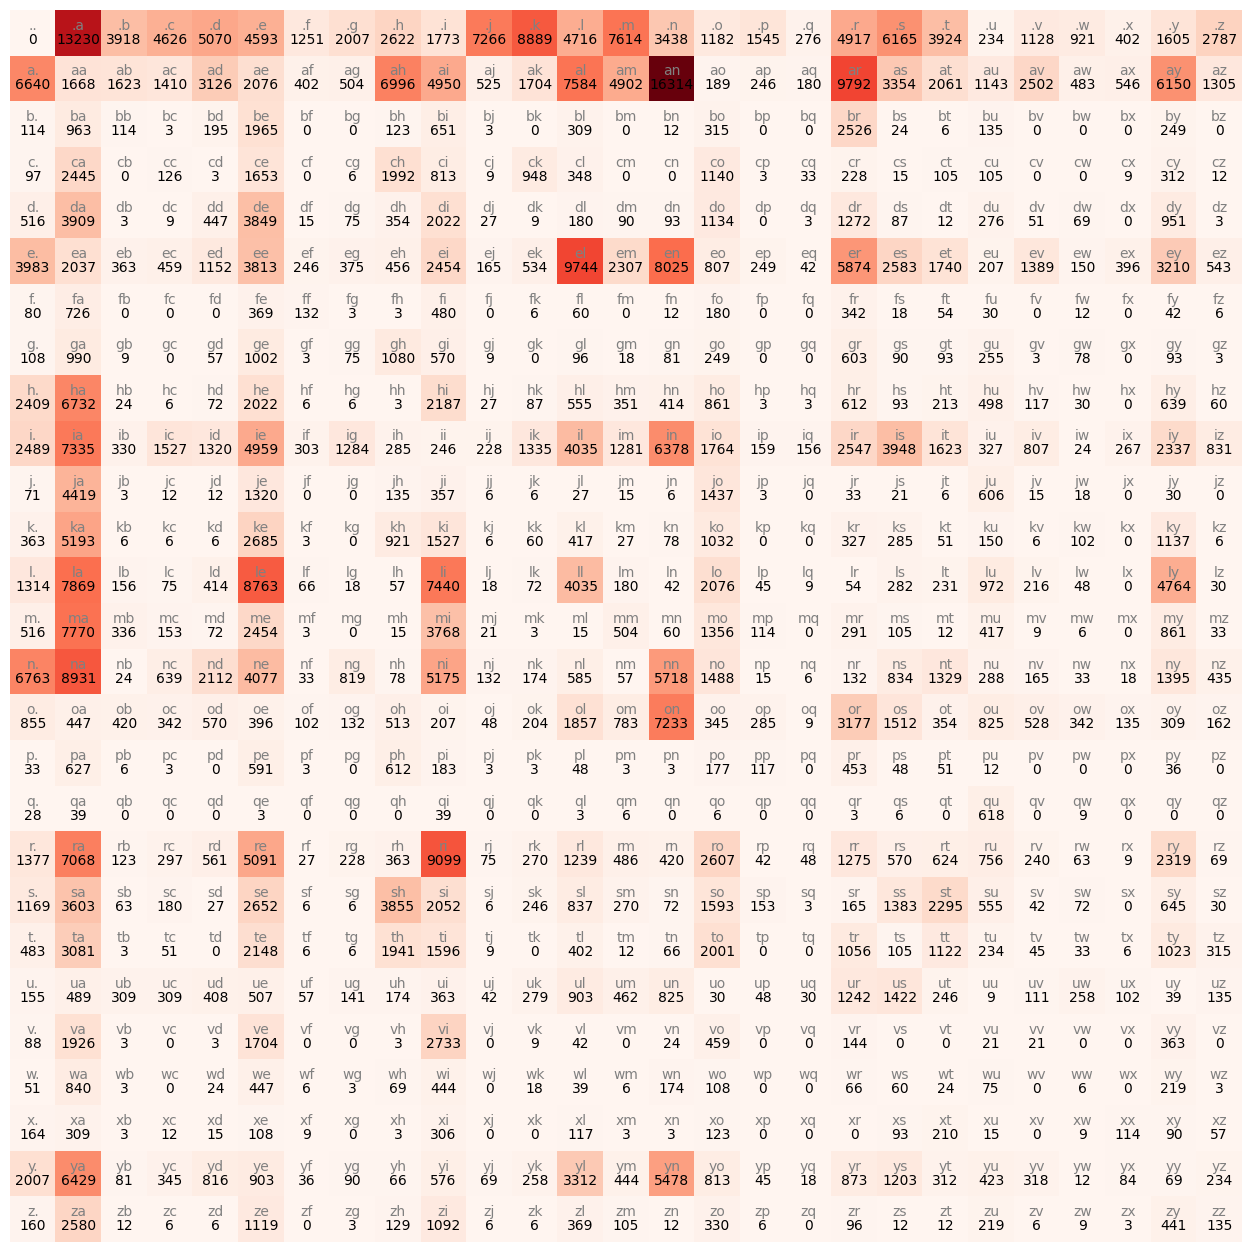

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (16, 16))
# This prints the whole matrix with color shades (weighed by count)
plt.imshow(N, cmap = 'Reds')

# iterate and add count and bigram
for i in range(27):
    for j in range(27):
        # bigram
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        # count (N[i, j].item() is count)
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = 'black')
plt.axis('off');

#### scrutinizing the matrix

* Last row is entirely 0
* last column is entirely 0

I think we can make it more efficient

In [13]:
# let's look at first row

N[0, :] # this is one dimensional array. This can also be depicted as 
N[0] # this is equivalent to above

tensor([    0, 13230,  3918,  4626,  5070,  4593,  1251,  2007,  2622,  1773,
         7266,  8889,  4716,  7614,  3438,  1182,  1545,   276,  4917,  6165,
         3924,   234,  1128,   921,   402,  1605,  2787], dtype=torch.int32)

In [25]:
# have to create probabilities, we want to normalize the count
# to create probability distribution
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [26]:

p.sum() # should be 1

tensor(1.)

---
#### Demo of generator and multinomial

In [23]:
# if we sample from this distribution
# torch.multinomial --> You give me probabilities, torch.multinomial will give me integers

g = torch.Generator().manual_seed(912345678) # This is not needed for production, this is only for maybe testing, to keep randomness under control or more predictive
pp = torch.rand(3, generator = g)
pp = pp / pp.sum()
pp

tensor([0.5302, 0.2763, 0.1935])

In [24]:
torch.multinomial(pp, num_samples = 20, replacement = True, generator = g)

tensor([2, 2, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 0, 0, 1, 0, 1, 0, 0])

we can see that  
probabilities are 53%, 27% and 20% roughly  
we see corresponding number of 0s, 1s and 2s

---

create bigram model (basically probabilities learned from distribution of bigram counter)

In [30]:
g = torch.Generator().manual_seed(912345678) # This is not needed for production, this is only for maybe testing, to keep randomness under control or more predictive
indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
itos[indexX]

'j'

if we look at row for '.j'

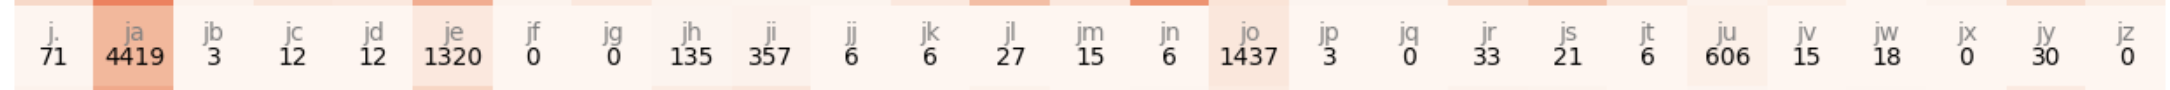

if we sample again, it should mostly follow probabilities

Then we can go on to write a loop

In [31]:
g = torch.Generator().manual_seed(912345678) 

for i in range(20):
    out = []
    indexX = 0
    while True:
        p = N[indexX].float()
        p = p / p.sum()
        indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(itos[indexX])
        if indexX == 0:
            break
    print(''.join(out))


ja.
rik.
sarexusayremovianeleshay.
jololarynga.
zeuialetynynayleelin.
atrantah.
zi.
bynarry.
ambi.
sosacoleliebrilya.
a.
arasuselen.
tonemarayspeindab.
kabamiprsedimtipamelionimyayscollennemis.
linghverakaynnahalrkyn.
hine.
elayshaya.
hallananahajeladon.
kikhacheely.
zana.


these are name like, but they are messed up.

The reason why this is so bad, is because it is bigram, and from model's perspective, it is only looking at one character at a time   
To actually see it is doing better than nothing.

let's switch to an equally distributed probabilities

---
compare bigram model (from learned probabilities) with equally distributed probabilities.

In [35]:
# equally distributed probabilities

g = torch.Generator().manual_seed(912345678) 

for i in range(20):
    out = []
    indexX = 0
    while True:
        # Equally distributed probabilities
        p = torch.ones(27) / 27.0
        # p = p / p.sum()
        indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(itos[indexX])
        if indexX == 0:
            break
    print(''.join(out))

f.
prib.
udrfxuvqyrfmovqdnxlqshwe.
jfggmdayxgq.
zkuiadezysyuvxleecttqbtrfptdh.
.
itbyjswtd.
ambw.
sbdocnooyiqbvclytkajxgzsukblenrxmnvptr.
yspggkdjb.
kzblmiprsbdimtipyxzltoqfmtgyscolpppcxmvskhvngcvlhdj.
qcnahaarkmpfhingxekaofhbybchazjpnjbmhxjglsdxzkktpfcciedjnuohxadbvneymoupdsy.
lwwcddgzzs.
qx.
wtvy.
a.
rhneh.
.
.
pzk.
